In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Yemeni Currency Recognition using YOLO-assisted CNN

This notebook presents the complete experimental pipeline for **Yemeni Banknote Recognition**.
It is designed as a **reproducible and presentation-oriented notebook**, while all heavy
processing (data preparation, training, evaluation) is handled by external scripts
located in the `src/` directory.

### Objectives
- Train currency classification models using **RAW images**
- Improve performance using **YOLO-based ROI extraction**
- Compare **RAW vs ROI** under identical experimental settings
- Evaluate robustness using **Bias Ablation** and **Grad-CAM**

### Dataset
- Yemeni paper currency banknotes
- Denominations: 50, 100, 200, 250, 500, 1000
- Publicly released via **Mendeley Data**

In [2]:
# Environment Setup
%cd /content/drive/MyDrive/Yemeni-Currency-Recognition
!pwd

/content/drive/MyDrive/Yemeni-Currency-Recognition
/content/drive/MyDrive/Yemeni-Currency-Recognition


In [ ]:
!pip install -r requirements.txt

In [ ]:
!pip uninstall -y jax jaxlib

In [1]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)
print("NumPy:", np.__version__)

TF: 2.19.0
NumPy: 2.0.2


In [7]:
import os
import json
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Reproducibility
os.environ["SEED"] = "1337"

# Training config
os.environ["IMG_SIZE"] = "224"
os.environ["BATCH"]    = "32"
os.environ["EPOCHS"]   = "10"
os.environ["N_FOLDS"]  = "5"


plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["font.size"] = 11
IMG_SIZE = (224, 224)
BATCH = 32

print("Environment ready")


Environment ready


In [8]:
%cd /content/drive/MyDrive/Yemeni-Currency-Recognition
!pwd

/content/drive/MyDrive/Yemeni-Currency-Recognition
/content/drive/MyDrive/Yemeni-Currency-Recognition


In [9]:
# Download  Dataset
!python src/data/download_yemeni.py

Download completed.
Extracting dataset...
Yemeni dataset ready at:
/content/Yemeni_data/RAW


In [10]:
from pathlib import Path

DATA_ROOT = Path('/content/Yemeni_data/RAW')
classes = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])

total_images = 0

print("Classes:", classes)
for c in classes:
    count = len(list((DATA_ROOT / c).glob("*")))
    total_images += count
    print(f"{c} : {count}")

print("Total images :", total_images)

Classes: ['100', '1000', '200', '250', '50', '500']
100 : 266
1000 : 276
200 : 267
250 : 287
50 : 290
500 : 305
Total images : 1691


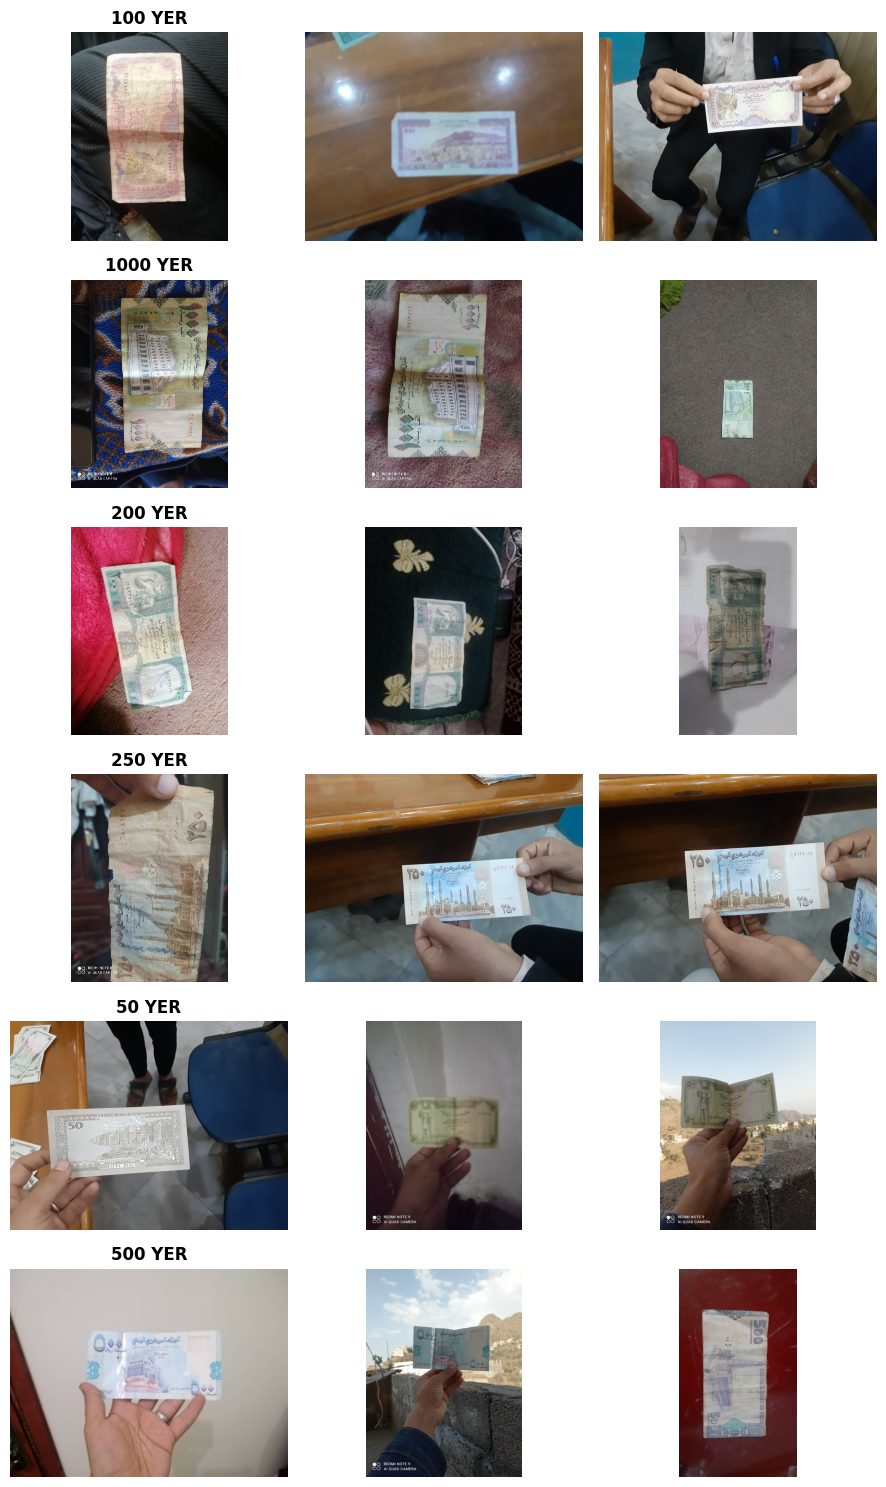

In [ ]:

# Visualize Sample Images

fig, axes = plt.subplots(len(classes), 3, figsize=(9, 2.5*len(classes)))

for i, cls in enumerate(classes):
    imgs = list((DATA_ROOT / cls).glob("*"))
    samples = random.sample(imgs, k=min(3, len(imgs)))

    for j, p in enumerate(samples):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(f"{cls} YER", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [11]:

# Stratified Split (15% Test + 5-Fold CV)
os.environ["RAW_ROOT"]   = "/content/Yemeni_data/RAW"
os.environ["TEST_ROOT"]  = "/content/Yemeni_data_test"
os.environ["FOLDS_ROOT"] = "/content/Yemeni_folds/raw"
os.environ["N_FOLDS"]    = "5"

!python src/data/split_cv.py

Total images: 1691
Classes: [np.str_('100'), np.str_('1000'), np.str_('200'), np.str_('250'), np.str_('50'), np.str_('500')]
Held-out test set created at: /content/Yemeni_data_test
Fold 1 created
Fold 2 created
Fold 3 created
Fold 4 created
Fold 5 created
5-Fold CV split completed successfully


In [ ]:

# Build ROI folds using YOLO
os.environ["RAW_FOLDS_ROOT"] = "/content/Yemeni_folds/raw"
os.environ["ROI_FOLDS_ROOT"] = "/content/Yemeni_folds/roi"
os.environ["YOLO_WEIGHTS"]   = "/content/drive/MyDrive/YOLO/banknote_detector/best.pt"

!python src/data/build_roi.py

In [ ]:
# RAW vs ROI Visual Comparison
RAW_SAMPLE = Path("/content/Yemeni_folds/raw/fold_1/train")
ROI_SAMPLE = Path("/content/Yemeni_folds/roi/fold_1/train")

cls = random.choice([d for d in RAW_SAMPLE.iterdir() if d.is_dir()])
img = random.choice(list(cls.glob("*")))

raw_img = cv2.cvtColor(cv2.imread(str(img)), cv2.COLOR_BGR2RGB)
roi_img = cv2.cvtColor(cv2.imread(str(ROI_SAMPLE/cls.name/img.name)), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); plt.imshow(raw_img); plt.title("RAW"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(roi_img); plt.title("ROI (YOLO)"); plt.axis("off")
plt.show()

#Train  Models

In [ ]:

# Train ROI Model
os.environ["FOLDS_ROOT"]   = "/content/Yemeni_folds/roi"
os.environ["EXP_NAME"]     = "Model 1(ROI)"
os.environ["RESULTS_ROOT"] = "/content/Yemeni_results/roi"

!python src/train/train.py

In [ ]:
# Train RAW Model

os.environ["FOLDS_ROOT"]   = "/content/Yemeni_folds/raw"
os.environ["EXP_NAME"]     = "Model 2"
os.environ["RESULTS_ROOT"] = "/content/Yemeni_results/raw"

!python src/train/train.py

In [ ]:
#Save the result to the drive


CONTENT_RESULTS = Path("/content/Yemeni_results")
DRIVE_RESULTS   = Path("/content/drive/MyDrive/Yemeni-Currency-Results")


DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)

shutil.copytree(CONTENT_RESULTS, DRIVE_RESULTS, dirs_exist_ok=True)

print(" Yemeni_results saved cleanly to Google Drive")


In [ ]:
import shutil
from pathlib import Path

DRIVE_RESULTS   = Path("/content/drive/MyDrive/Yemeni-Currency-Results")
CONTENT_RESULTS = Path("/content/Yemeni_results")

# Clean old content results
if CONTENT_RESULTS.exists():
    shutil.rmtree(CONTENT_RESULTS)

# Copy back
shutil.copytree(DRIVE_RESULTS, CONTENT_RESULTS)

print(" Results restored from Drive to Colab")

In [13]:

# Cross-validation Results

res_raw = json.load(open("/content/Yemeni_results/raw/cv_results.json"))
res_roi = json.load(open("/content/Yemeni_results/roi/cv_results.json"))

df = pd.DataFrame({
    "Fold": range(1,6),
    "RAW Val Acc": res_raw["val_acc"],
    "ROI Val Acc": res_roi["val_acc"]
})

display(df)

print(f"RAW  Mean: {np.mean(res_raw['val_acc'])*100:.2f}%")
print(f"ROI  Mean: {np.mean(res_roi['val_acc'])*100:.2f}%")
print(f"Gain     : {(np.mean(res_roi['val_acc'])-np.mean(res_raw['val_acc']))*100:+.2f}%")


,Fold,RAW Val Acc,ROI Val Acc
0,1,1.000000,0.996528
1,2,1.000000,0.993056
2,3,0.993031,1.000000
3,4,0.996516,0.989547
4,5,0.996516,0.996516


RAW  Mean: 99.72%
ROI  Mean: 99.51%
Gain     : -0.21%


In [14]:
best_raw_idx = int(np.argmax(res_raw["val_acc"]))
best_roi_idx = int(np.argmax(res_roi["val_acc"]))

raw_model = tf.keras.models.load_model(
    f"/content/Yemeni_results/raw/model_fold{best_raw_idx}.keras"
)
roi_model = tf.keras.models.load_model(
    f"/content/Yemeni_results/roi/model_fold{best_roi_idx}.keras"
)

print(f"Best RAW Fold: {best_raw_idx+1}")
print(f"Best ROI Fold: {best_roi_idx+1}")

Best RAW Fold: 1
Best ROI Fold: 3


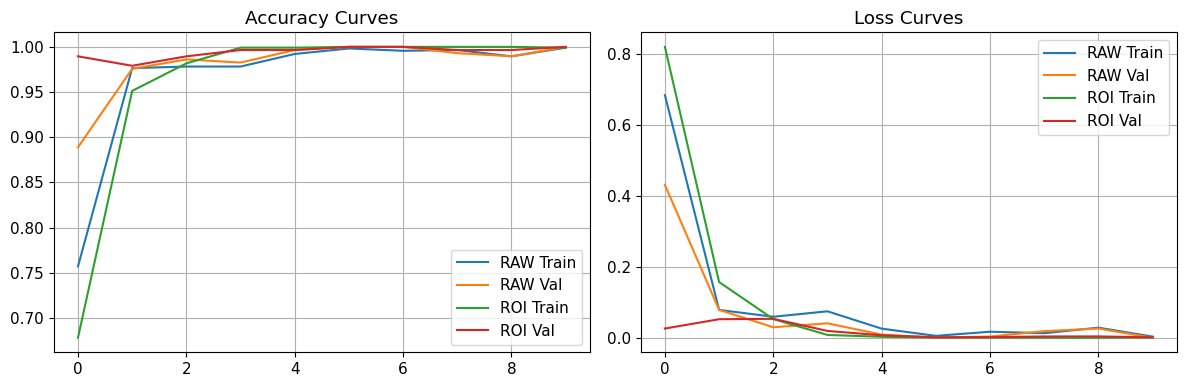

In [ ]:
#Training Curves
hist_raw = json.load(open("/content/Yemeni_results/raw/histories.json"))[best_raw_idx]
hist_roi = json.load(open("/content/Yemeni_results/roi/histories.json"))[best_roi_idx]

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(hist_raw["acc"], label="RAW Train")
plt.plot(hist_raw["val_acc"], label="RAW Val")
plt.plot(hist_roi["acc"], label="ROI Train")
plt.plot(hist_roi["val_acc"], label="ROI Val")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(hist_raw["loss"], label="RAW Train")
plt.plot(hist_raw["val_loss"], label="RAW Val")
plt.plot(hist_roi["loss"], label="ROI Train")
plt.plot(hist_roi["val_loss"], label="ROI Val")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#Test Evaluation

In [20]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Yemeni_data_test",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

class_names = test_ds.class_names
print("Classes:", class_names)


Found 254 files belonging to 6 classes.
Classes: ['100', '1000', '200', '250', '50', '500']


In [21]:
# Final Test Evaluation (Held-out Test)
raw_loss, raw_acc = raw_model.evaluate(test_ds, verbose=0)
roi_loss, roi_acc = roi_model.evaluate(test_ds, verbose=0)

df_test = pd.DataFrame({
    "Model": ["RAW", "ROI"],
    "Accuracy": [raw_acc, roi_acc],
    "Loss": [raw_loss, roi_loss]
})

display(df_test)

print(f"Accuracy Gain (ROI − RAW): {(roi_acc - raw_acc)*100:+.2f}%")

,Model,Accuracy,Loss
0,RAW,1.000000,0.000087
1,ROI,0.996063,0.016127


Accuracy Gain (ROI − RAW): -0.39%


#Confusion Matrix

In [22]:
def collect_preds(model, ds):
    y_true, y_pred = [], []
    for x, y in ds:
        p = model.predict(x, verbose=0).argmax(axis=1)
        y_true.extend(y.numpy())
        y_pred.extend(p)
    return np.array(y_true), np.array(y_pred)

# RAW
y_t_raw, y_p_raw = collect_preds(raw_model, test_ds)
cm_raw = confusion_matrix(y_t_raw, y_p_raw)

# ROI
y_t_roi, y_p_roi = collect_preds(roi_model, test_ds)
cm_roi = confusion_matrix(y_t_roi, y_p_roi)

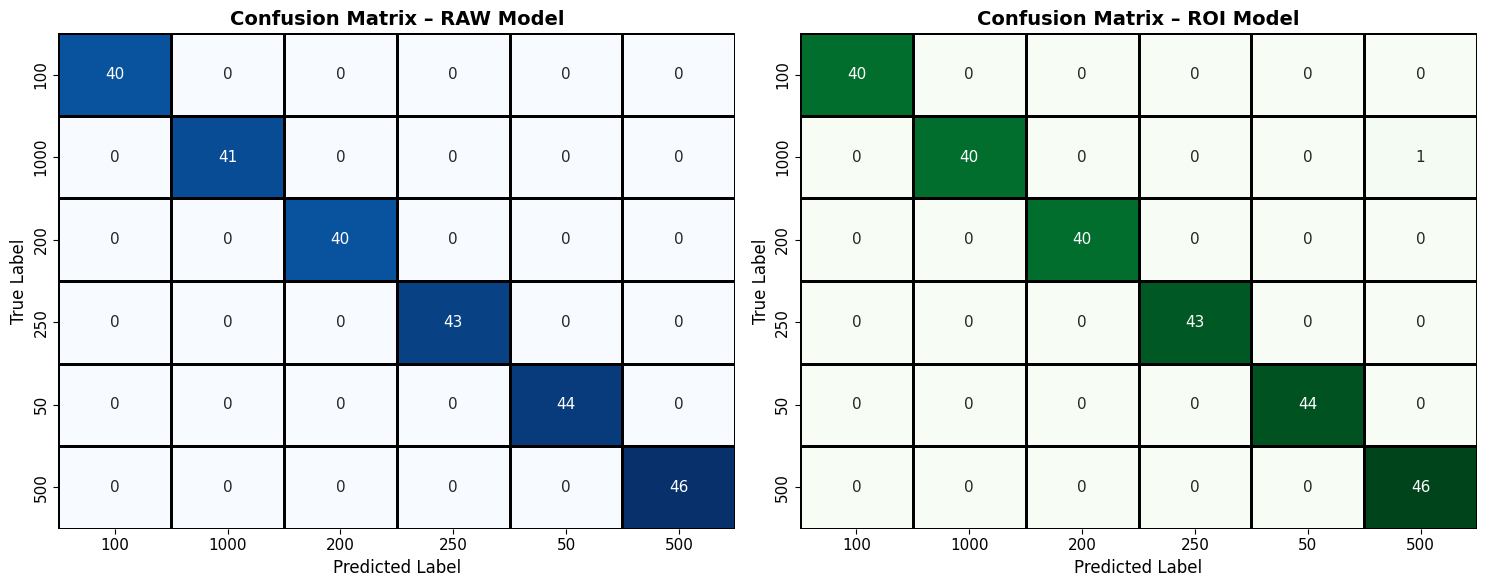

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# === RAW Confusion Matrix ===
sns.heatmap(
    cm_raw,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.8,
    linecolor='black',
    cbar=False,
    ax=ax1
)
ax1.set_title('Confusion Matrix – RAW Model', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)

# === ROI Confusion Matrix ===
sns.heatmap(
    cm_roi,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.8,
    linecolor='black',
    cbar=False,
    ax=ax2
)
ax2.set_title('Confusion Matrix – ROI Model', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
##Classification Report

from sklearn.metrics import classification_report

# === RAW Classification Report ===
print("="*60)
print("CLASSIFICATION REPORT – RAW MODEL")
print("="*60)

report_raw = classification_report(
    y_t_raw,
    y_p_raw,
    target_names=class_names,
    digits=4
)
print(report_raw)

# === ROI Classification Report ===
print("="*60)
print("CLASSIFICATION REPORT – ROI MODEL")
print("="*60)

report_roi = classification_report(
    y_t_roi,
    y_p_roi,
    target_names=class_names,
    digits=4
)
print(report_roi)


CLASSIFICATION REPORT – RAW MODEL
              precision    recall  f1-score   support

         100     1.0000    1.0000    1.0000        40
        1000     1.0000    1.0000    1.0000        41
         200     1.0000    1.0000    1.0000        40
         250     1.0000    1.0000    1.0000        43
          50     1.0000    1.0000    1.0000        44
         500     1.0000    1.0000    1.0000        46

    accuracy                         1.0000       254
   macro avg     1.0000    1.0000    1.0000       254
weighted avg     1.0000    1.0000    1.0000       254

CLASSIFICATION REPORT – ROI MODEL
              precision    recall  f1-score   support

         100     1.0000    1.0000    1.0000        40
        1000     1.0000    0.9756    0.9877        41
         200     1.0000    1.0000    1.0000        40
         250     1.0000    1.0000    1.0000        43
          50     1.0000    1.0000    1.0000        44
         500     0.9787    1.0000    0.9892        46

    accur

## Only one classification error in the ROI model

Number of ROI misclassifications: 1


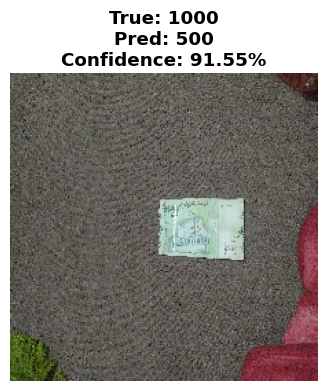

In [ ]:
#  Extract and Visualize ROI Misclassification
import numpy as np
import matplotlib.pyplot as plt

mis_samples = []

for x_batch, y_batch in test_ds:
    preds = roi_model.predict(x_batch, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(len(y_batch)):
        if pred_labels[i] != y_batch[i]:
            mis_samples.append({
                "image": x_batch[i].numpy(),
                "true": int(y_batch[i]),
                "pred": int(pred_labels[i]),
                "conf": float(np.max(preds[i]))
            })

print(f"Number of ROI misclassifications: {len(mis_samples)}")


sample = mis_samples[0]

plt.figure(figsize=(4,4))
plt.imshow(sample["image"].astype("uint8"))
plt.axis("off")
plt.title(
    f"True: {class_names[sample['true']]}\n"
    f"Pred: {class_names[sample['pred']]}\n"
    f"Confidence: {sample['conf']*100:.2f}%",
    fontweight="bold"
)
plt.show()


# Bias Ablation
 Original vs Background-only (RAW vs ROI)



In [34]:

# Bias Ablation (ROI)

os.environ["TEST_ROOT"]    = "/content/Yemeni_data_test"
os.environ["RESULTS_ROOT"] = "/content/Yemeni_results/roi"

os.environ["YOLO_WEIGHTS"] = "/content/drive/MyDrive/YOLO/banknote_detector/best.pt"

!python src/eval/bias_ablation.py

2025-12-29 15:41:05.198820: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767022865.218355   15576 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767022865.224234   15576 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767022865.239175   15576 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767022865.239205   15576 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767022865.239209   15576 computation_placer.cc:177] computation placer alr

In [35]:
#BIAS ABLATION – RAW MODEL
from tensorflow import keras

# Paths
TEST_ROOT = Path("/content/Yemeni_data_test")
BG_ROOT   = Path("/content/data_bg_only/test")
RAW_ROOT  = Path("/content/Yemeni_results/raw")

# Load best RAW model
with open(RAW_ROOT/"cv_results.json") as f:
    cv = json.load(f)

best_fold = int(tf.argmax(cv["val_acc"]))
raw_model = keras.models.load_model(RAW_ROOT/f"model_fold{best_fold}.keras")

print(f"Using RAW model from fold {best_fold+1}")

# Datasets
def make_ds(root):
    return keras.utils.image_dataset_from_directory(
        root,
        image_size=IMG_SIZE,
        batch_size=BATCH,
        label_mode="int",
        shuffle=False
    )

raw_ds = make_ds(TEST_ROOT)
bg_ds  = make_ds(BG_ROOT)

# Evaluate
_, acc_raw = raw_model.evaluate(raw_ds, verbose=0)
_, acc_bg  = raw_model.evaluate(bg_ds,  verbose=0)

bbc = (acc_raw - acc_bg) / acc_raw * 100

print("="*50)
print("BIAS ABLATION – RAW MODEL")
print("="*50)
print(f"RAW acc (normal): {acc_raw*100:.2f}%")
print(f"BG  acc (background-only): {acc_bg*100:.2f}%")
print(f"BBC (drop): {bbc:.2f}%")


Using RAW model from fold 1
Found 254 files belonging to 6 classes.
Found 254 files belonging to 6 classes.
BIAS ABLATION – RAW MODEL
RAW acc (normal): 100.00%
BG  acc (background-only): 27.95%
BBC (drop): 72.05%


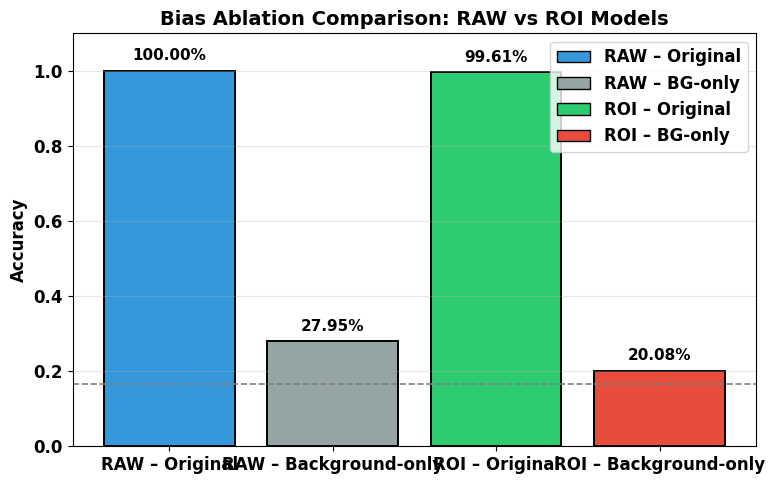

In [36]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Random Chance (16.67%)
# Load ROI bias results
bias_roi = json.load(open("/content/Yemeni_results/roi/bias_ablation.json"))

raw_acc_normal = acc_raw
raw_acc_bg     = acc_bg

# Build unified dataframe
df_bias_all = pd.DataFrame({
    "Model": ["RAW", "RAW", "ROI", "ROI"],
    "Test Set": ["Original", "Background-only", "Original", "Background-only"],
    "Accuracy": [
        raw_acc_normal,
        raw_acc_bg,
        bias_roi["raw_acc"],
        bias_roi["bg_acc"]
    ]
})

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

colors = {
    ("RAW", "Original"): "#3498db",
    ("RAW", "Background-only"): "#95a5a6",
    ("ROI", "Original"): "#2ecc71",
    ("ROI", "Background-only"): "#e74c3c"
}

x_labels = [
    "RAW – Original",
    "RAW – Background-only",
    "ROI – Original",
    "ROI – Background-only"
]

values = df_bias_all["Accuracy"].values
bar_colors = [colors[(m, t)] for m, t in zip(df_bias_all["Model"], df_bias_all["Test Set"])]

bars = ax.bar(
    x_labels,
    values,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.4
)

# Axes & title
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Bias Ablation Comparison: RAW vs ROI Models",
             fontsize=14, fontweight="bold")

# Random chance line
ax.axhline(
    y=1/6,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="Random Chance (16.67%)"
)

# Value labels
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.02,
        f"{h*100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#3498db", edgecolor="black", label="RAW – Original"),
    Patch(facecolor="#95a5a6", edgecolor="black", label="RAW – BG-only"),
    Patch(facecolor="#2ecc71", edgecolor="black", label="ROI – Original"),
    Patch(facecolor="#e74c3c", edgecolor="black", label="ROI – BG-only"),
]
ax.legend(handles=legend_elements, loc="upper right")

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#Grad-CAM

In [45]:
# === Grad-CAM (Final – Stable Version) ===
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from pathlib import Path

# Best ROI model
best_roi_idx = np.argmax(res_roi["val_acc"])
model_roi = tf.keras.models.load_model(
    f"/content/Yemeni_results/roi/model_fold{best_roi_idx}.keras"
)

print(f"Using best ROI model: Fold {best_roi_idx + 1}")

# Backbone
base_model = model_roi.get_layer("efficientnetv2-s")
last_conv_layer = base_model.get_layer("top_conv")

# Grad-CAM model (backbone only – SAFE)
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output]
)

Using best ROI model: Fold 3


In [51]:
def make_gradcam_heatmap(img_array, pred_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

def overlay_heatmap(img, heatmap, alpha=0.4):
    """Overlay heatmap on original image"""
    img = np.uint8(img)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    return heatmap_resized, overlay


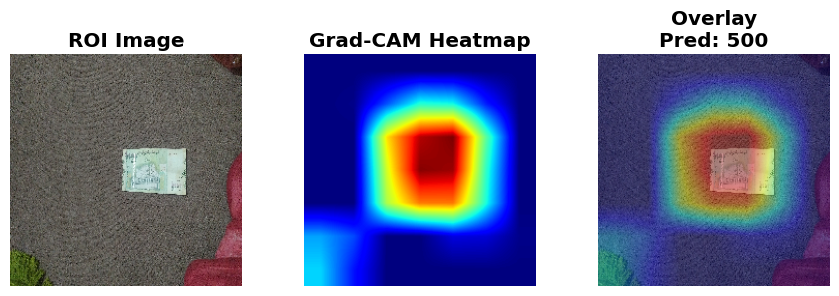

In [49]:
#  Grad-CAM for the Misclassified ROI Sample
import numpy as np
import matplotlib.pyplot as plt

x_single = np.expand_dims(sample["image"], axis=0)

heatmap = make_gradcam_heatmap(x_single, pred_index=sample["pred"])
hm, overlay = overlay_heatmap(sample["image"], heatmap)

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(sample["image"].astype("uint8"))
plt.title("ROI Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(hm, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title(
    f"Overlay\nPred: {class_names[sample['pred']]}",
    fontweight="bold"
)
plt.axis("off")

plt.tight_layout()
plt.show()


Found 254 files belonging to 6 classes.
Classes: ['100', '1000', '200', '250', '50', '500']


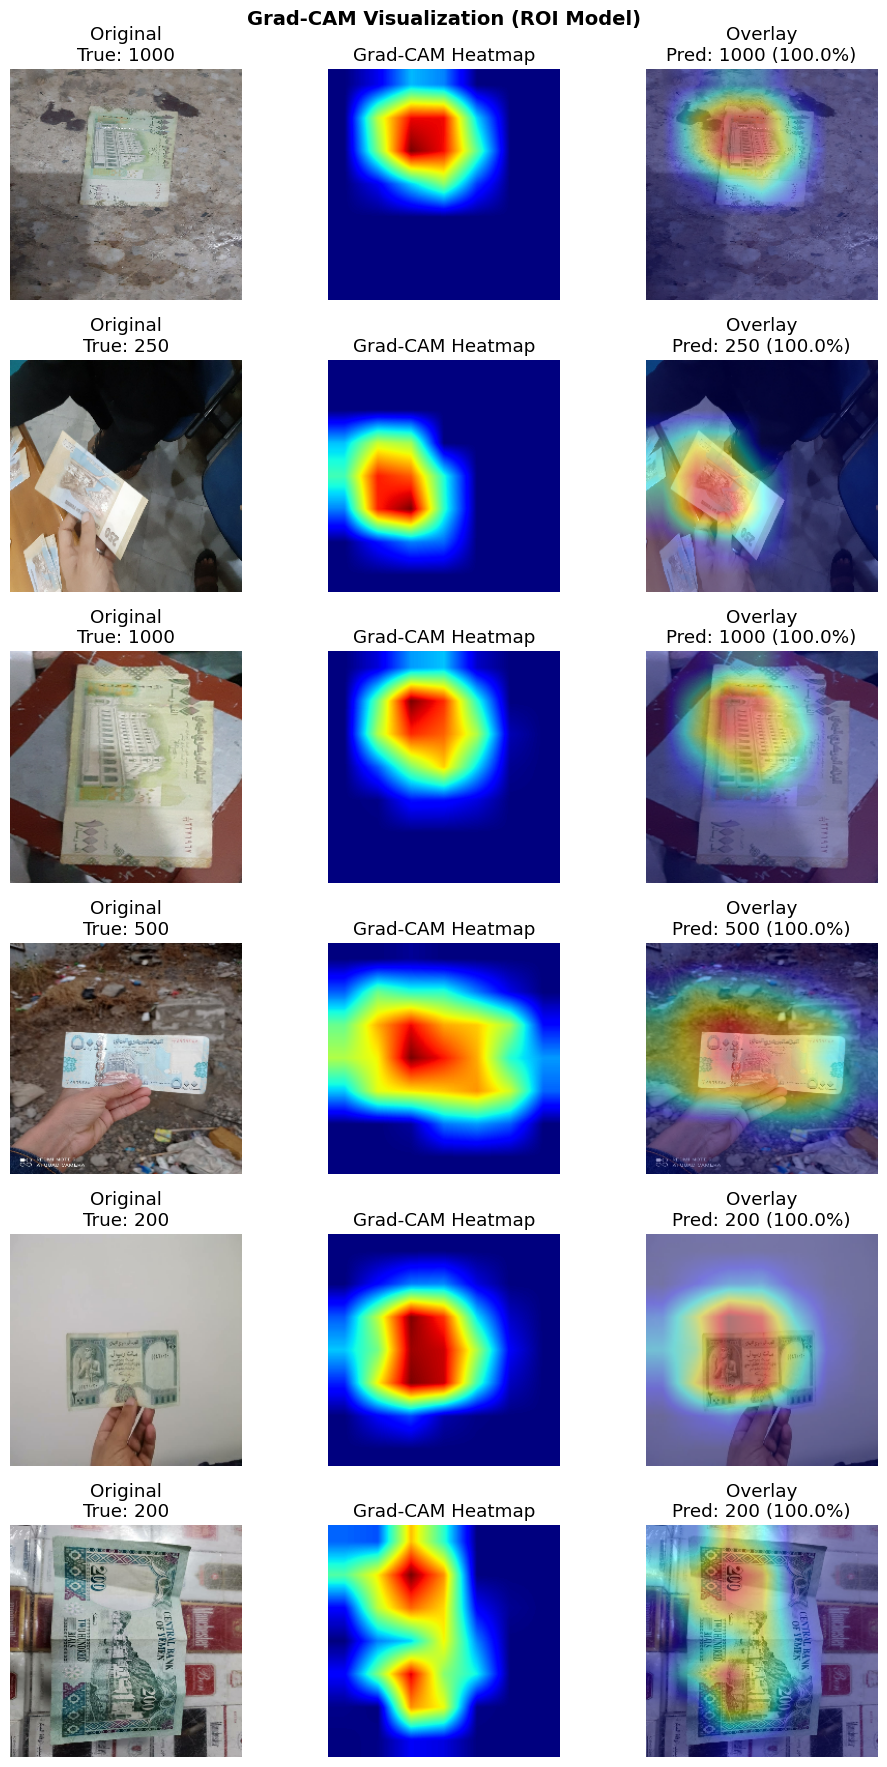

In [ ]:
# = GRAD-CAM VISUALIZATION ===

# Load test dataset
import tensorflow as tf

TEST_DIR = "/content/Yemeni_data_test"
IMG_SIZE = (224, 224)
BATCH = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="int",
    shuffle=False
)

class_names = test_ds.class_names
print("Classes:", class_names)


# Collect images and labels
all_imgs, all_labels = [], []
for xb, yb in test_ds.unbatch():
    all_imgs.append(xb.numpy())
    all_labels.append(int(yb.numpy()))

# Select 6 random samples (one from each class if possible)
num_images = 6
idxs = random.sample(range(len(all_imgs)), num_images)

# Create visualization
fig, axes = plt.subplots(num_images, 3, figsize=(10, num_images * 3))
fig.suptitle("Grad-CAM Visualization (ROI Model)", fontsize=14, fontweight='bold')

for i, idx in enumerate(idxs):
    x_single = np.expand_dims(all_imgs[idx], axis=0)
    y_true = all_labels[idx]

    # Predict
    preds = model_roi.predict(x_single, verbose=0)
    y_pred = np.argmax(preds[0])
    confidence = preds[0][y_pred] * 100

    # Generate Grad-CAM
    heatmap = make_gradcam_heatmap(x_single, pred_index=y_pred)

    img = all_imgs[idx].astype("uint8")
    hm, overlay = overlay_heatmap(img, heatmap)

    # Display
    axes[i, 0].imshow(img)
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"Original\nTrue: {class_names[y_true]}")

    axes[i, 1].imshow(hm, cmap='jet')
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f"Grad-CAM Heatmap")

    axes[i, 2].imshow(overlay)
    axes[i, 2].axis('off')
    axes[i, 2].set_title(f"Overlay\nPred: {class_names[y_pred]} ({confidence:.1f}%)")

plt.tight_layout()
plt.show()



## Conclusion – Yemeni Currency Recognition

This notebook demonstrated a complete and reproducible pipeline for Yemeni
banknote recognition. While RAW image-based classification achieved marginally
higher accuracy on the held-out test set, the YOLO-assisted ROI pipeline showed
comparable performance with only a single misclassification.

Bias ablation experiments indicate that both models significantly degrade under
background-only inputs, confirming that classification decisions are driven by
currency-specific features rather than background artifacts. Grad-CAM
visualizations further support this observation by highlighting discriminative
regions on the banknotes.

Overall, the proposed detection–classification pipeline provides a robust and
interpretable framework, particularly valuable for controlled deployments and
cross-dataset generalization.


#Run API

In [ ]:
%cd /content/drive/MyDrive/Yemeni-Currency-Recognition
!pwd

/content/drive/MyDrive/Yemeni-Currency-Recognition
/content/drive/MyDrive/Yemeni-Currency-Recognition


In [ ]:
!python run_inference.py --image "/content/F1000_ (92).jpg"

E0000 00:00:1766780760.862393   36430 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766780760.893730   36430 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766780760.955519   36430 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766780760.958001   36430 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766780760.958026   36430 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766780760.958035   36430 computation_placer.cc:177] computation placer already registered. Please check linka

In [ ]:
!nohup python api/main.py > server.log 2>&1 &

In [ ]:
!curl http://127.0.0.1:8085/

{"message":"Yemeni Currency API is running","status":"ok"}

In [ ]:
!curl -X POST "http://127.0.0.1:8085/predict" \
  -H "accept: application/json" \
  -H "Content-Type: multipart/form-data" \
  -F "file=@/content/B100_ (35).jpg"

{"currency":"100","confidence":1.0}

In [ ]:
!curl -X POST "http://127.0.0.1:8085/predict" \
  -H "accept: application/json" \
  -H "Content-Type: multipart/form-data" \
  -F "file=@/content/F1000_41 (6).jpg"


{"currency":"1000","confidence":1.0}

In [ ]:
!curl -X POST "http://127.0.0.1:8085/predict" \
  -H "accept: application/json" \
  -H "Content-Type: multipart/form-data" \
  -F "file=@/content/B250_09 (23).jpg"


{"currency":"250","confidence":1.0}